# 📊 Explorando activos financieros con Python y pandas
## Análisis exploratorio de activos de un portafolio

En este laboratorio aprenderás a obtener datos financieros, explorarlos con **pandas**, transformarlos y encontrar información útil para analizar activos.

> **Idea clave:** primero observamos los datos, después calculamos y finalmente interpretamos.


## 🧭 Ruta de aprendizaje

**1. Conectar con los datos** → Yahoo Finance y tickers  
**2. Conocer la información** → DataFrame y estructura  
**3. Mirar antes de calcular** → exploración inicial  
**4. Seguir el comportamiento** → precios y gráficos  
**5. Medir los cambios** → rendimientos  
**6. Describir lo encontrado** → estadísticas  
**7. Comparar para comprender** → varios activos  
**8. Buscar relaciones** → correlación  
**9. Tu análisis** → misión individual


# 1. 🔌 Conectar con los datos

### ¿De dónde obtenemos la información?

Yahoo Finance contiene información histórica de diferentes activos financieros. Para acceder a ella desde Python utilizaremos **yfinance**.

Un **ticker** es el código utilizado para identificar un activo. Por ejemplo: `AAPL`, `MSFT`, `AMZN` o `GOOGL`.


In [1]:
!pip -q install yfinance

In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Nuestro primer activo

Comencemos con Apple. Más adelante cambiaremos el ticker para trabajar con los activos asignados.

In [4]:
ticker = "AAPL"

datos = yf.download(
    ticker,
    start="2020-01-01",
    end="2025-01-01",
    auto_adjust=False
)

datos.head() #trae los primeros 5 registros, si en el parentesis se pone un numero, me trae esa cantidad

[*********************100%***********************]  1 of 1 completed


Price,Adj Close,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,,
2020-01-02,72.271530,75.087502,75.150002,73.797501,74.059998,135480400
2020-01-03,71.568924,74.357498,75.144997,74.125000,74.287498,146322800
2020-01-06,72.139191,74.949997,74.989998,73.187500,73.447502,118387200
2020-01-07,71.799919,74.597504,75.224998,74.370003,74.959999,108872000
2020-01-08,72.954933,75.797501,76.110001,74.290001,74.290001,132079200


# 2. 🧩 Conocer la información

Lo que acabamos de obtener es un **DataFrame de pandas**: una estructura de datos organizada en filas y columnas.

Antes de analizar, necesitamos saber qué contiene la tabla y cómo está organizada.


In [5]:
datos.head()# trae los primeros 5 registros

Price,Adj Close,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,,
2020-01-02,72.271530,75.087502,75.150002,73.797501,74.059998,135480400
2020-01-03,71.568924,74.357498,75.144997,74.125000,74.287498,146322800
2020-01-06,72.139191,74.949997,74.989998,73.187500,73.447502,118387200
2020-01-07,71.799919,74.597504,75.224998,74.370003,74.959999,108872000
2020-01-08,72.954933,75.797501,76.110001,74.290001,74.290001,132079200


In [ ]:
datos.tail()#trae los ultimos 5 registros

Price,Adj Close,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,,
2024-12-24,256.339752,258.200012,258.209991,255.289993,255.490005,23234700
2024-12-26,257.153839,259.019989,260.100006,257.630005,258.190002,27237100
2024-12-27,253.748535,255.589996,258.700012,253.059998,257.829987,42355300
2024-12-30,250.382965,252.199997,253.500000,250.750000,252.229996,35557500
2024-12-31,248.615799,250.419998,253.279999,249.429993,252.440002,39480700


In [6]:
datos.shape

(1258, 6)

In [8]:
datos.info() #  indica cuantos datos hay en cada columna

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1258 entries, 2020-01-02 to 2024-12-31
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   (Adj Close, AAPL)  1258 non-null   float64
 1   (Close, AAPL)      1258 non-null   float64
 2   (High, AAPL)       1258 non-null   float64
 3   (Low, AAPL)        1258 non-null   float64
 4   (Open, AAPL)       1258 non-null   float64
 5   (Volume, AAPL)     1258 non-null   int64  
dtypes: float64(5), int64(1)
memory usage: 68.8 KB


### 🧠 Piensa

- ¿Qué representa una fila?
- ¿Qué representa una columna?
- ¿Qué información contiene el índice?
- ¿Cuántas observaciones tenemos?

Estas preguntas forman parte del **análisis exploratorio de datos**.

# 3. 🔎 Mirar antes de calcular

Una exploración inicial nos ayuda a detectar características, diferencias o posibles problemas antes de comenzar a realizar cálculos.

In [ ]:
datos.describe()

Price,Adj Close,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL
count,1258.000000,1258.000000,1258.000000,1258.000000,1258.000000,1.258000e+03
mean,151.247343,154.108800,155.660348,152.379123,153.951948,9.057103e+07
std,41.815934,41.520877,41.654310,41.305929,41.466618,5.324438e+07
min,54.117035,56.092499,57.125000,53.152500,57.020000,2.323470e+07
25%,126.170277,129.624996,130.755005,127.505001,129.017506,5.546825e+07
50%,149.839409,152.805000,154.570000,150.825005,152.575005,7.628335e+07
75%,175.750465,178.850006,180.160000,177.115005,178.500004,1.077425e+08
max,257.153839,259.019989,260.100006,257.630005,258.190002,4.265100e+08


In [9]:
datos.isna().sum()#identifica cuantos valoes nulos hay

,,0
Price,Ticker,
Adj Close,AAPL,0
Close,AAPL,0
High,AAPL,0
Low,AAPL,0
Open,AAPL,0
Volume,AAPL,0


### 🧠 Interpreta

No basta con ejecutar `describe()`. Observa los resultados y piensa: ¿qué nos permite conocer cada medida sobre los datos?

# 4. 📈 Seguir el comportamiento

Comencemos observando el precio de cierre. Una gráfica puede ayudarnos a identificar tendencias y cambios que serían difíciles de observar en una tabla.

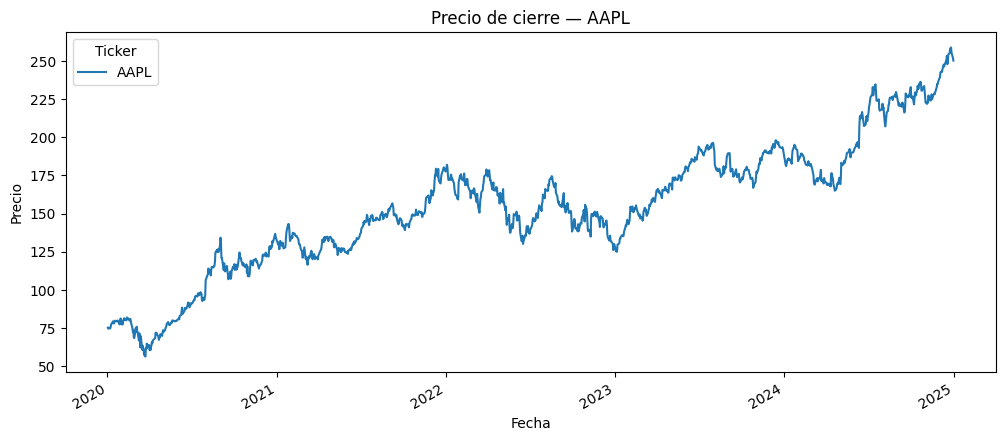

In [ ]:
cierre = datos["Close"]

cierre.plot(figsize=(12, 5))
plt.title(f"Precio de cierre — {ticker}")
plt.xlabel("Fecha")
plt.ylabel("Precio")
plt.show()

### 👀 Observa

Describe brevemente lo que encuentras:

- ¿Se observan períodos de crecimiento o disminución?
- ¿Hay cambios especialmente fuertes?
- ¿El comportamiento parece estable durante todo el período?


# 5. 🔄 Medir los cambios

Comparar solamente precios puede ser insuficiente porque los activos pueden comenzar con valores muy diferentes.

Una alternativa es estudiar los **rendimientos**, que expresan el cambio de una observación respecto a la anterior.


### Cálculo de Rendimientos Financieros

Existen dos formas principales de calcular los rendimientos financieros: discretos y logarítmicos.

#### 1. Rendimientos Discretos (o Simples)

Los rendimientos discretos representan el cambio porcentual en el precio de un activo entre dos períodos consecutivos. Son intuitivos y fáciles de interpretar, ya que reflejan directamente la ganancia o pérdida en relación con el precio inicial. Son adecuados para el cálculo de rendimientos de un solo período.

La fórmula para el rendimiento discreto $R_t$ en el período $t$ es:

$$\Large R_t = \frac{P_t - P_{t-1}}{P_{t-1}} = \frac{P_t}{P_{t-1}} - 1$$

Donde:
*   $P_t$ es el precio del activo en el tiempo $t$.
*   $P_{t-1}$ es el precio del activo en el tiempo $t-1$.

### Ejemplo de Cálculo de Rendimientos

Consideremos los siguientes precios:
*   Precio Anterior ($P_{t-1}$): **100**
*   Precio Actual ($P_t$): **110**

#### 1. Cálculo del Rendimiento Discreto

Utilizando la fórmula:

$$\Large R_t = \frac{P_t - P_{t-1}}{P_{t-1}} = \frac{110 - 100}{100} = \frac{10}{100} = 0.10$$

El rendimiento discreto es **0.10** o **10%**.


In [15]:
rendimiento = cierre.pct_change()  #Calcula el rendimiento de los datos de cierre
rendimiento.head()

Ticker,AAPL
Date,
2020-01-02,NaN
2020-01-03,-0.009722
2020-01-06,0.007968
2020-01-07,-0.004703
2020-01-08,0.016086


El primer valor aparece como `NaN` porque no existe una observación anterior con la cual compararlo.


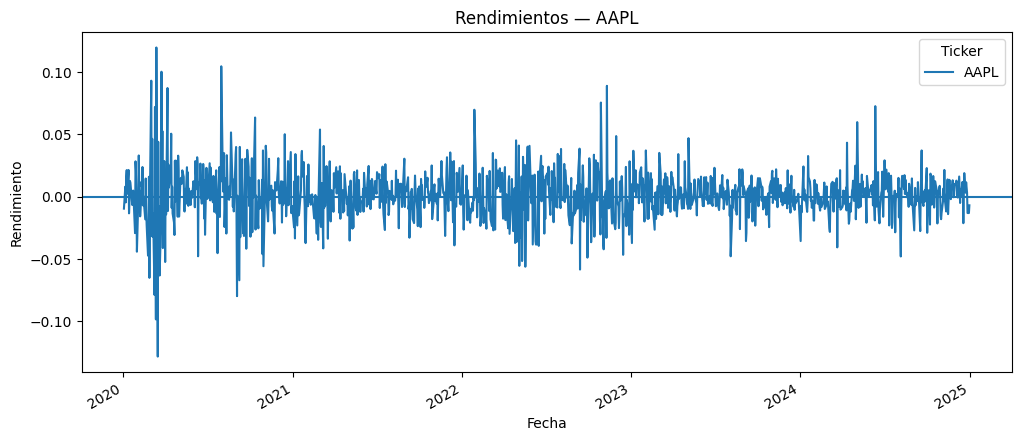

In [ ]:
rendimiento.plot(figsize=(12, 5))

plt.axhline(0)
plt.title(f"Rendimientos — {ticker}")
plt.xlabel("Fecha")
plt.ylabel("Rendimiento")
plt.show()

# 6. 📐 Describir lo encontrado

Ahora podemos utilizar las estadísticas descriptivas para conocer mejor la distribución de los rendimientos.

In [ ]:
rendimiento.describe()

Ticker,AAPL
count,1257.000000
mean,0.001157
std,0.019957
min,-0.128647
25%,-0.008425
50%,0.001172
75%,0.011989
max,0.119808


### Interpretación de las Estadísticas Descriptivas de Rendimientos

Al analizar la tabla de estadísticas descriptivas para los rendimientos, observamos lo siguiente:

*   **Promedio (Mean):** El promedio de los rendimientos es cercano a cero (aproximadamente 0.1157%). Esto sugiere que, a lo largo del periodo analizado, el rendimiento diario promedio del activo ha sido muy bajo, lo cual es común en series de rendimientos diarios que no muestran una tendencia marcada a largo plazo.

*   **Desviación Estándar (Std):** La desviación estándar es de aproximadamente 1.99%. Esta medida nos indica la dispersión o volatilidad de los rendimientos diarios. Un valor del 2% diario significa que, en promedio, los rendimientos suelen desviarse en un 2% (ya sea al alza o a la baja) de la media. En el contexto financiero, una mayor desviación estándar implica una mayor volatilidad y, por ende, un mayor riesgo.

*   **Mínimo (Min):** El rendimiento mínimo observado es de aproximadamente -12.86%. Esto representa la mayor pérdida porcentual experimentada por el activo en un solo día durante el periodo. Si se hubieran invertido 100 pesos, una pérdida del 12.86% implicaría que el valor de la inversión se reduciría a 87.14 pesos en ese día.

*   **Máximo (Max):** El rendimiento máximo observado es de aproximadamente 11.98%. Esta es la mayor ganancia porcentual en un solo día. Es notable que la máxima pérdida (-12.86%) es ligeramente superior a la máxima ganancia (11.98%), lo que podría indicar una asimetría en los movimientos extremos del activo, con pérdidas más severas en ciertos días.

*   **Percentil 25% (Q1):** El primer cuartil es de -0.84%. Esto significa que el 25% de los días, el rendimiento del activo fue igual o inferior a -0.84%, lo que implica una pérdida para el 25% de las observaciones.

*   **Percentil 50% (Mediana):** La mediana (percentil 50%) es de aproximadamente 0.1172%. Esto indica que el 50% de los rendimientos fueron iguales o inferiores a este valor, y el otro 50% fueron iguales o superiores. Al ser cercano a cero y ligeramente positivo, refuerza la idea de que los rendimientos oscilan alrededor de cero.

*   **Percentil 75% (Q3):** El tercer cuartil es de 1.19%. Esto significa que el 75% de los días, el rendimiento del activo fue igual o inferior a 1.19%, o dicho de otra forma, el 25% de los días la rentabilidad fue superior a 1.19%.

**Ausencia de tendencia y oscilación alrededor de cero:** Esto es típico en las series de rendimientos de activos. A diferencia de los precios, que suelen mostrar tendencias alcistas o bajistas a largo plazo, los rendimientos diarios (o periódicos) tienden a fluctuar en torno a su promedio (que a menudo es cercano a cero). Esto indica que, en el corto plazo, los movimientos positivos y negativos se compensan, sin una dirección clara y sostenida.

**Dispersión alrededor de cero y su variabilidad (Volatilidad)**: Has identificado correctamente que la dispersión de los rendimientos alrededor de cero no es constante. Esta dispersión se mide con la desviación estándar, y en el ámbito financiero se conoce como volatilidad. Una mayor dispersión (picos más altos o valles más profundos) significa mayor volatilidad, lo que implica que el precio del activo está experimentando cambios más grandes en un corto período de tiempo. Los periodos de "alta dispersión" se correlacionan con alta volatilidad (mayor riesgo), mientras que los de "baja dispersión" indican baja volatilidad (menor riesgo).

**Rangos de máximos y mínimos (Variabilidad Extrema):** La observación de que los rendimientos máximos superan el 10% y los mínimos caen por debajo del -10% es crucial. Esto te da una idea del rango extremo de movimientos que el activo ha experimentado en un solo día. Rendimientos tan altos o tan bajos en un solo día son eventos significativos que reflejan la magnitud de los shocks o noticias que afectaron al activo en esos momentos.

# Percentiles extremos


In [ ]:
print("Percentil 1:", rendimiento.quantile(0.01))
print("Percentil 5:", rendimiento.quantile(0.05))

Percentil 1: Ticker
AAPL   -0.050317
Name: 0.01, dtype: float64
Percentil 5: Ticker
AAPL   -0.030125
Name: 0.05, dtype: float64


## Interpretación de Percentiles como Pérdida Máxima Esperada (VaR)

Los percentiles 1 y 5 de los rendimientos son a menudo interpretados en el contexto de **Valor en Riesgo (VaR)**, una medida clave en finanzas para cuantificar la pérdida potencial de una inversión.

*   El **percentil 1** de aproximadamente -0.050317 (-5.03%) significa que existe un **1% de probabilidad** de que el activo experimente una pérdida de 5.03% o más de su valor en un día determinado, bajo condiciones normales de mercado. Esto se puede entender como la **máxima pérdida esperada** que el activo podría sufrir con un nivel de confianza del 99% (es decir, hay solo un 1% de posibilidades de que la pérdida real sea mayor).

*   El **percentil 5** de aproximadamente -0.030125 (-3.01%) significa que existe un **5% de probabilidad** de que el activo experimente una pérdida de 3.01% o más de su valor en un día determinado. Esto se interpreta como la **máxima pérdida esperada** con un nivel de confianza del 95% (hay un 5% de posibilidades de que la pérdida real sea mayor).

En resumen, estos valores proporcionan una estimación de las pérdidas extremas que un inversor podría enfrentar con este activo en un día, junto con la probabilidad de que ocurran.

In [16]:
print("Promedio:", rendimiento.mean())
print("Desviación estándar:", rendimiento.std())
print("Mínimo:", rendimiento.min())
print("Máximo:", rendimiento.max())

Promedio: Ticker
AAPL    0.001157
dtype: float64
Desviación estándar: Ticker
AAPL    0.019957
dtype: float64
Mínimo: Ticker
AAPL   -0.128647
dtype: float64
Máximo: Ticker
AAPL    0.119808
dtype: float64


### 🧠 Interpreta

¿Qué nos dice el promedio? ¿Qué información aporta la desviación estándar? ¿Qué representan los valores mínimo y máximo?

Recuerda: **una estadística tiene sentido cuando podemos explicar qué significa en el contexto financiero.**

# 7. ⚖️ Comparar para comprender

Ahora incorporaremos varios activos. La comparación nos permitirá observar diferencias en su comportamiento.

In [5]:
import yfinance as yf
activos = ["APPL", "MSFT", "AMZN"]

datos = yf.download(
    activos,
    start="2020-01-01",
    end="2025-01-01",
    auto_adjust=False
)

precios = datos["Close"]
precios.head()

ERROR:yfinance:HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: APPL"}}}
[*********************100%***********************]  3 of 3 completed
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['APPL']: YFTzMissingError('possibly delisted; no timezone found')


Ticker,AMZN,APPL,MSFT
Date,,,
2020-01-02,94.900497,NaN,160.619995
2020-01-03,93.748497,NaN,158.619995
2020-01-06,95.143997,NaN,159.029999
2020-01-07,95.343002,NaN,157.580002
2020-01-08,94.598503,NaN,160.089996


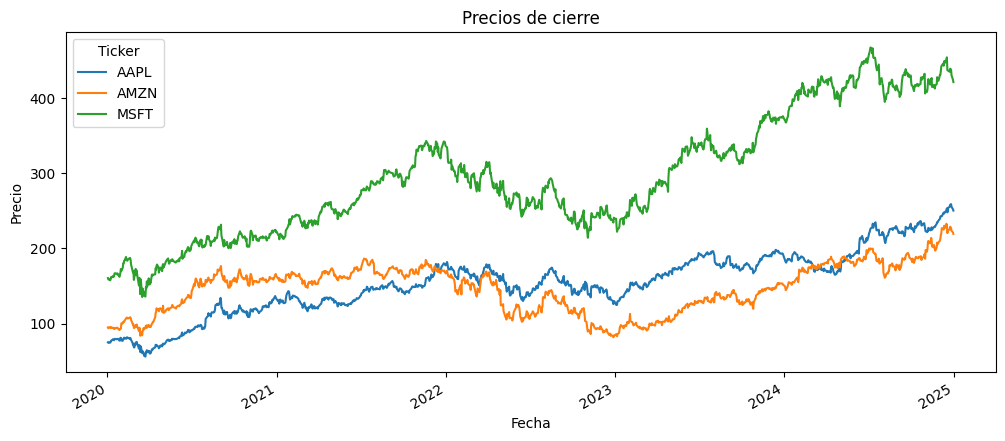

In [ ]:
precios.plot(figsize=(12, 5))

plt.title("Precios de cierre")
plt.xlabel("Fecha")
plt.ylabel("Precio")
plt.show()

Los precios pueden tener escalas diferentes. Para comparar su evolución desde un mismo punto de referencia podemos construir un índice base 100.

### Normalización de Precios (Base 100)

Para comparar la evolución de diferentes activos financieros, es útil **normalizar sus precios a una base común**, como 100. Esto permite observar cómo ha crecido o disminuido el valor de cada activo desde un punto de partida equitativo, independientemente de sus precios absolutos iniciales.

La fórmula para normalizar un precio $P_t$ en el tiempo $t$ a una base 100 es:

$$\Large P_{t, \text{normalizado}} = \frac{P_t}{P_0} \times 100$$

Donde:
*   $P_t$ es el precio del activo en el tiempo $t$.
*   $P_0$ es el precio inicial (o precio en el punto de partida) del activo.

#### Ejemplo:

Supongamos que tenemos los siguientes precios para un activo en tres días:

*   Día 1 ($P_0$): **75.00**
*   Día 2 ($P_1$): **74.35**
*   Día 3 ($P_2$): **74.95**

Aplicando la fórmula de normalización:

*   **Día 1:** $\frac{75.00}{75.00} \times 100 = 100$
*   **Día 2:** $\frac{74.35}{75.00} \times 100 \approx 99.13$
*   **Día 3:** $\frac{74.95}{75.00} \times 100 \approx 99.93$

Estos valores normalizados nos permiten ver el cambio porcentual relativo de cada día respecto al día inicial (base 100).

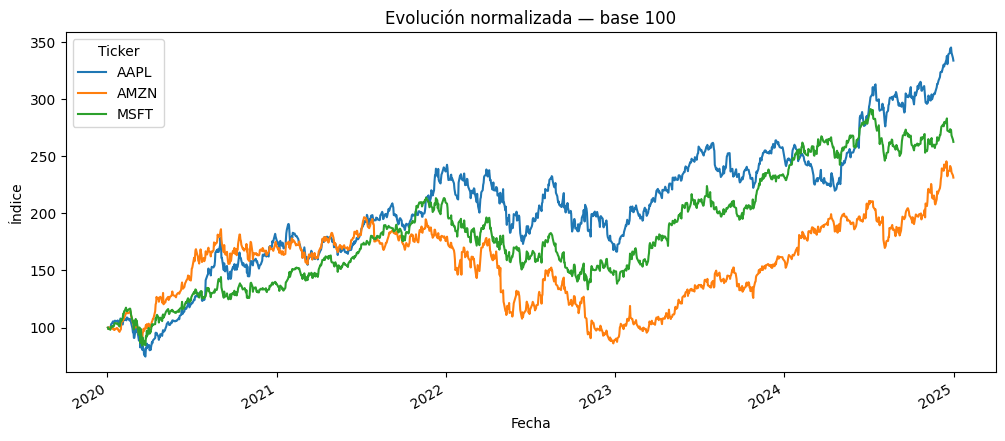

In [ ]:
precios_normalizados = precios / precios.iloc[0] * 100

precios_normalizados.plot(figsize=(12, 5))
plt.title("Evolución normalizada — base 100")
plt.xlabel("Fecha")
plt.ylabel("Índice")
plt.show()

# 8. 🔗 Buscar relaciones

En un portafolio no solo importa cómo se comporta cada activo individualmente. También interesa saber cómo se relacionan entre sí.

Primero calculamos los rendimientos de todos los activos.

In [ ]:
rendimientos = precios.pct_change()
rendimientos.head()

Ticker,AAPL,AMZN,MSFT
Date,,,
2020-01-02,NaN,NaN,NaN
2020-01-03,-0.009722,-0.012139,-0.012452
2020-01-06,0.007968,0.014886,0.002585
2020-01-07,-0.004703,0.002092,-0.009118
2020-01-08,0.016086,-0.007809,0.015928


In [ ]:
correlacion = rendimientos.corr()
correlacion

Ticker,AAPL,AMZN,MSFT
Ticker,,,
AAPL,1.000000,0.591883,0.748121
AMZN,0.591883,1.000000,0.678666
MSFT,0.748121,0.678666,1.000000


### Análisis Financiero de la Matriz de Correlación

La matriz de correlación de los rendimientos es una herramienta fundamental en finanzas para entender la relación entre los movimientos de diferentes activos y es clave para la **diversificación de carteras**.

*   **Correlación Positiva (cercana a +1):** Indica que los rendimientos de los activos tienden a moverse en la misma dirección. Si el rendimiento de un activo sube, es muy probable que el del otro también lo haga, y viceversa. En nuestra matriz, podemos observar una fuerte correlación positiva entre **AAPL y MSFT (0.748)**. Esto significa que si las acciones de Apple suben, las de Microsoft probablemente también lo harán, y si bajan, las de Microsoft también tenderán a bajar. Una correlación alta reduce los beneficios de la diversificación, ya que los activos no actúan como "amortiguadores" el uno del otro en momentos de caída.

*   **Correlación Negativa (cercana a -1):** Sugiere que los rendimientos de los activos tienden a moverse en direcciones opuestas. Si un activo sube, el otro tiende a bajar, y viceversa. Este tipo de correlación es muy deseable para la diversificación, ya que ayuda a mitigar el riesgo de la cartera. En nuestra matriz, no observamos correlaciones negativas fuertes, lo cual es común entre acciones del mismo sector o mercado.

*   **Correlación Cero (cercana a 0):** Implica que no hay una relación lineal predecible entre los movimientos de los rendimientos de los activos. Su comportamiento es independiente el uno del otro. Aunque no reduce el riesgo tan eficazmente como una correlación negativa, sigue siendo beneficioso para la diversificación en comparación con una correlación positiva alta.

#### Implicaciones para la Diversificación:

Para construir un portafolio robusto y diversificado, se busca incluir activos con **baja o negativa correlación**. Esto se debe a que, si un activo experimenta una caída, es probable que otro activo con baja o negativa correlación no caiga (o incluso suba), compensando así parte de la pérdida. Los activos en nuestra matriz muestran correlaciones positivas entre sí, lo que sugiere que son algo dependientes. Por ejemplo, **AAPL** y **AMZN** tienen una correlación de **0.592**, y **AMZN** y **MSFT** de **0.679**. Esto indica que, aunque no se mueven en perfecta sintonía, sus rendimientos sí comparten una tendencia común.

Para mejorar la diversificación, un inversor podría considerar añadir activos de diferentes sectores, geografías o tipos (por ejemplo, bonos, materias primas) que históricamente muestren una correlación más baja o negativa con los activos tecnológicos actuales.

### ¿Cómo podemos leer la correlación?

- Cerca de **1**: los movimientos tienden a ser similares.
- Cerca de **0**: la relación lineal es débil.
- Cerca de **-1**: los movimientos tienden a ser opuestos.

### 💭 Pregunta

Si dos activos presentan una correlación elevada, ¿qué podría significar esto al pensar en diversificación?

# 9. 🚀 Tu análisis

Ahora repite el proceso con los **activos que te fueron asignados**.

Tu análisis debe seguir esta secuencia:

**Obtener → Conocer → Explorar → Transformar → Describir → Comparar → Relacionar → Interpretar**

### Tu misión

1. Obtén los datos históricos desde Yahoo Finance.
2. Explora la estructura del DataFrame.
3. Revisa los datos y los valores faltantes.
4. Observa el comportamiento de los precios.
5. Calcula los rendimientos.
6. Describe los rendimientos con estadísticas.
7. Compara visualmente los activos.
8. Explora la correlación.
9. Escribe una conclusión sustentada en los resultados.

> **Pregunta final:** ¿Qué diferencias encontraste entre los activos y qué información consideras importante conocer antes de incorporarlos a un portafolio?


## 🎫 Salida de aprendizaje

Completa estas tres frases en una celda de texto:

- **Encontré que…**
- **La información que más me ayudó a comparar los activos fue…**
- **Antes de construir un portafolio, considero importante revisar…**


In [4]:
sector = yf.Ticker("IBM")

print(sector.info["sector"])

Technology


In [6]:
activos = ["IBM","WFC","XOM","MRK","KO","GE"]

datos = yf.download(
    activos,
    start="2019-01-01",
    end="2026-01-01",
    auto_adjust=False
)

precios = datos["Close"]
precios.head()

[*********************100%***********************]  6 of 6 completed


Ticker,GE,IBM,KO,MRK,WFC,XOM
Date,,,,,,
2019-01-02,38.579121,110.143402,46.930000,72.127861,46.939999,69.690002
2019-01-03,38.627045,107.944550,46.639999,70.648857,46.570000,68.620003
2019-01-04,39.441761,112.160614,47.570000,72.776718,47.950001,71.150002
2019-01-07,41.885902,112.954109,46.950001,71.975189,47.639999,71.519997
2019-01-08,41.023266,114.560226,47.480000,72.509544,47.540001,72.040001


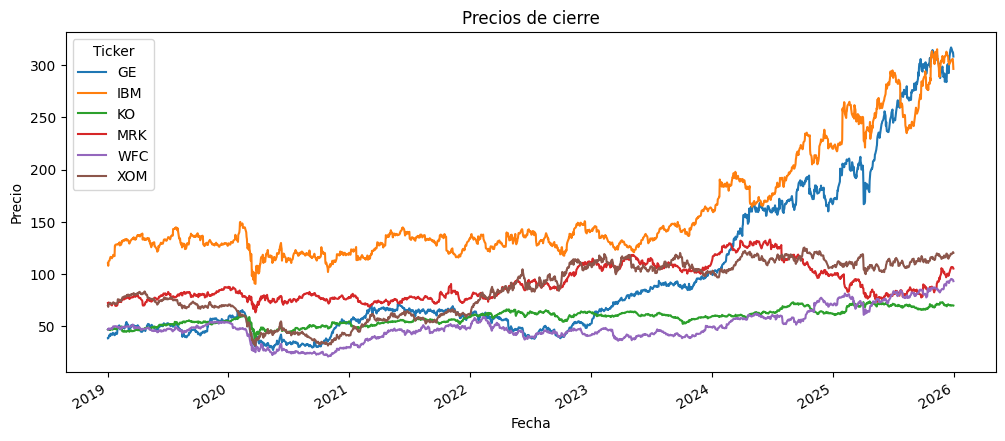

In [10]:
precios.plot(figsize=(12, 5))

plt.title("Precios de cierre")
plt.xlabel("Fecha")
plt.ylabel("Precio")
plt.show()

Como se ve en el gráfico, IBM tiene el precio absoluto más alto casi todo el periodo, mientras que WFC y KO se mueven en un rango de precio mucho más bajo. Pero el precio absoluto no dice si un activo "rindió mejor".

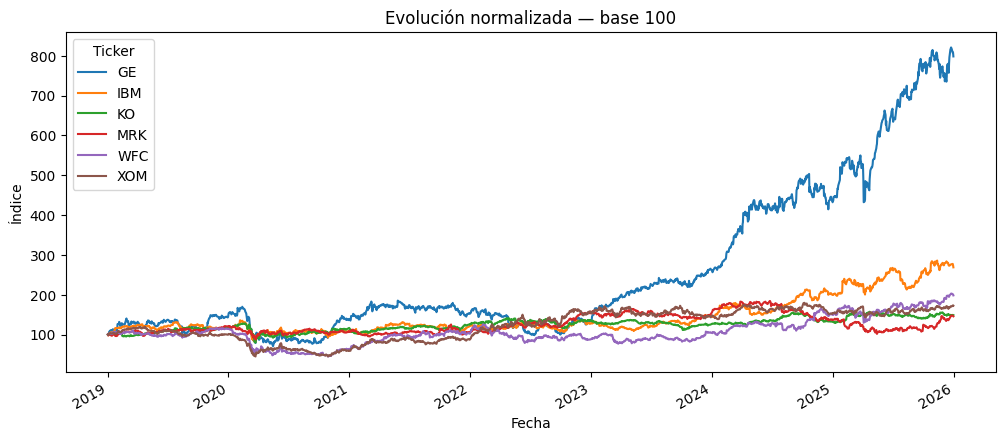

In [11]:
precios_normalizados = precios / precios.iloc[0] * 100

precios_normalizados.plot(figsize=(12, 5))
plt.title("Evolución normalizada — base 100")
plt.xlabel("Fecha")
plt.ylabel("Índice")
plt.show()

Con esto vemos el crecimiento porcentual de cada acción desde el mismo punto de partida. Se nota que GE tuvo el mejor desempeño relativo: su valor llegó a superar 800 en el índice, es decir, se multiplicó por más de 8 veces desde 2019. IBM quedó muy por debajo, cerca de 280, y el resto de los activos se mantuvo entre 100 y 200 durante todo el periodo.


In [12]:
rendimientos = precios.pct_change()
rendimientos.head()

Ticker,GE,IBM,KO,MRK,WFC,XOM
Date,,,,,,
2019-01-02,NaN,NaN,NaN,NaN,NaN,NaN
2019-01-03,0.001242,-0.019964,-0.006179,-0.020505,-0.007882,-0.015354
2019-01-04,0.021092,0.039058,0.019940,0.030119,0.029633,0.036870
2019-01-07,0.061968,0.007075,-0.013033,-0.011014,-0.006465,0.005200
2019-01-08,-0.020595,0.014219,0.011289,0.007424,-0.002099,0.007271


In [13]:
correlacion = rendimientos.corr()
correlacion

Ticker,GE,IBM,KO,MRK,WFC,XOM
Ticker,,,,,,
GE,1.000000,0.447325,0.358556,0.219232,0.551940,0.465005
IBM,0.447325,1.000000,0.458614,0.310117,0.482719,0.430059
KO,0.358556,0.458614,1.000000,0.399229,0.395858,0.370327
MRK,0.219232,0.310117,0.399229,1.000000,0.246326,0.249764
WFC,0.551940,0.482719,0.395858,0.246326,1.000000,0.526685
XOM,0.465005,0.430059,0.370327,0.249764,0.526685,1.000000


# **ANALISIS DE MATRIX DE CORRELACIÓN**
En nuestro caso, la relación más fuerte se da entre WFC y GE, con un valor de 0.55, lo que indica que estas dos acciones tienden a subir y bajar juntas con más frecuencia que el resto de las combinaciones. En el otro extremo, la relación más débil es la de MRK y GE, con apenas 0.22, lo que muestra que estos dos activos se mueven de manera bastante independiente entre sí. Es importante notar que ninguna correlación resultó negativa, y tampoco encontramos valores realmente altos, ya que todas las combinaciones se ubican en un rango entre 0.2 y 0.55. Esto nos permite concluir que existe una correlación positiva moderada entre los seis activos: comparten cierta tendencia común, probablemente porque todos cotizan en el mismo mercado y responden hasta cierto punto a las mismas condiciones económicas generales, pero no se mueven pegados unos con otros como pasaría si estuvieran en el mismo sector o fueran empresas muy similares en su modelo de negocio

# **CONCLUSIÓN**
Aunque los seis activos pertenecen a sectores distintos, como tecnología, banca, energía, farmacéutica, consumo básico e industrial, sus rendimientos diarios muestran una correlación positiva moderada entre sí, ubicándose todos los valores entre 0.22 y 0.55. Esto tiene sentido, ya que todos cotizan en el mismo mercado y suelen reaccionar, hasta cierto punto, a las mismas noticias económicas generales, como cambios en tasas de interés o eventos que afectan a la economía en su conjunto. Sin embargo, dentro de este grupo se pueden notar diferencias importantes: MRK destaca por tener las correlaciones más bajas con el resto de los activos, especialmente con GE, donde apenas llega a 0.22, lo que la convierte en la opción más útil para diversificar dentro de este portafolio. Por otro lado, GE y WFC presentan la correlación más alta, con un valor de 0.55, lo que indica que estas dos acciones tienden a moverse de forma bastante parecida y, por lo tanto, ofrecen menos beneficio de diversificación si se combinan juntas dentro de una misma cartera

# **¿Qué diferencias encontraste entre los activos y qué información consideras importante conocer antes de incorporarlos a un portafolio?**

Encontré diferencias claras tanto en crecimiento como en riesgo entre los seis activos. GE tuvo, por lejos, el mejor desempeño acumulado, llegando a multiplicar su valor más de 8 veces desde 2019, mientras que activos como KO y MRK se mantuvieron mucho más estables, con un crecimiento menor pero también con menor volatilidad diaria, lo que los hace más predecibles en el corto plazo. Antes de incorporar estos activos a un portafolio, es importante conocer no solo el rendimiento pasado de cada uno, sino también su volatilidad, es decir, qué tanto suben y bajan sus precios día a día, ya que esto refleja el nivel de riesgo que se está asumiendo. Y sobre todo, es fundamental revisar la correlación entre los activos, porque combinar acciones que se mueven de forma muy parecida entre sí no reduce realmente el riesgo del portafolio, mientras que incluir activos con correlaciones más bajas, como MRK, permite que las caídas de unos se compensen mejor con el comportamiento de otros.




**Salida de aprendizaje**

-Encontré que los seis activos se comportan de forma distinta: GE creció muchísimo más que los demás, mientras que KO y MRK fueron más estables y menos riesgosos, y todos los activos tienen una correlación positiva moderada entre ellos (ninguno se mueve totalmente independiente ni en dirección opuesta).

-La información que más me ayudó a comparar los activos fue la evolución normalizada en base 100, porque muestra el crecimiento porcentual de cada acción desde el mismo punto de partida, sin que el precio en dólares de cada una distorsione la comparación.

-Antes de construir un portafolio, considero importante revisar la correlación entre los activos, ya que si todos tienen una correlación alta entre sí (cercana a 1), el portafolio pierde el beneficio de la diversificación: cuando uno cae, es probable que todos caigan juntos. En cambio, combinar activos con correlación baja o negativa, como MRK con el resto, ayuda a que las pérdidas de un activo se compensen mejor con el comportamiento de otro.